<a href="https://colab.research.google.com/github/jrhumberto/zhbquantico/blob/main/Qiskit/034_QML_quantum_kernels.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [17]:
# Função Utilitária para conectividade com computador quântico real
import os
def getColabFile(var='token', file='ibm_token.json', google_drive= False):
    path = None
    try:
        from google.colab import userdata
        if google_drive:
            from google.colab import drive
            drive.mount('/content/drive')
            path = f'/content/drive/MyDrive/{file}'
        else:
            path =  f'{file}'
        return userdata.get(var)
    except:  #  SecretNotFoundError or ImportError
        try:
            import json
            return json.load(open(file)).get(var, None) if os.path.exists(path) else None
        except:
            return None

getToken = lambda var='token', default='<ERROR>': getColabFile() or os.getenv(var) or os.environ.get(var, default)

# QML Quantum Kernels

**Implementador**: Humberto BM Junior  
**Data**: 04/04/2026  
**Referência**: www.youtube.com/watch?v=eNkKcvOfa_0

## Conceito

* Núcleo quântico é kernel matrix e entradas na mesma, onde quantum kernel method é método que usa processador quântico para estimar kernel;

* Função de kernel quântico visa similaridade entre pontos de dados, onde cada ponto é codificado como estado quântico via feature maps, e kernel é calculado como sobreposição (overlap) entre estados quânticos;

* Os códigos Qiskit, em exemplo, exibem profundidade dos circuitos quânticos de codificação pré-codificados que usam emaranhamento substancial.

## Passo a passo

1. Mapear entradas clássicas para problema quântico: codificar dados de entrada em circuito quântico (feature map), mapeando vetores de dados para estados no espaço de Hilbert e permitindo calcular produto interno entre 2 dados;

    * Entrada: conjunto de dados de treinamento;

    * Saída: circuito abstrato para calcular entrada da matriz do kernel.

2. Otimizar problema para execução quântica: aplicar rotinas de otimização do Qiskit para adaptar circuito ao backend quântico escolhido, reduzindo profundidade e erros;

    * Entrada: circuito abstrato, não otimizado para backend específico;

    * Saída: circuito-alvo e observável, otimizado para QPU selecionada (real ou simulador).

3. Executar usando primitivas de Qiskit Runtime: executar circuito e obter distribuição de probabilidades (ou quase-probabilidades) dos estados medidos;

    * Entrada: circuito alvo;

    * Saída: distribuição de probabilidade.

4. Pós-processamento, retornar resultado no formato clássico: extrair probabilidade do estado resultante e usá-la para preencher elemento da matriz de kernel, que depois será utilizada em algoritmos clássicos ML.

    * Entrada: distribuição de probabilidade;

    * Saída: único elemento da matriz de kernel, ou matriz de kernel se estiver repetindo.

## Implementação

In [18]:
# !pip install qiskit qiskit-aer qiskit-ibm-runtime scikit-learn pandas numpy matplotlib -q

In [19]:
from qiskit. circuit.library import z_feature_map, unitary_overlap
from qiskit.circuit import Parameter, ParameterVector, QuantumCircuit
from qiskit.primitives import StatevectorSampler
from qiskit. transpiler.preset_passmanagers import generate_preset_pass_manager
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, SamplerV2 as Sampler
from qiskit. visualization import plot_distribution
from sklearn.svm import SVC
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### SINGLE KERNEL MATRIX

In [20]:
small_data = [
  [-0.194, 0.114, -0.006, 0.301, -0.359, -0.088, -0.156, 0.342, -0.016, 0.143, 1],
  [-0.1, 0.002, 0.244, 0.127, -0.064, -0.086, 0.072, 0.043, -0.053, 0.02, -1],
]

train_data = [small_data[0][:- 1], small_data[1][:-1]]

In [21]:
fm = z_feature_map(feature_dimension=np.shape(train_data)[1])
unitary1 = fm.assign_parameters(train_data[0])
unitary2 = fm.assign_parameters(train_data[1])

In [22]:
overlap_circ = unitary_overlap(unitary1, unitary2)
overlap_circ.measure_all("m")


In [23]:
print("Profundidade do circuito:", overlap_circ.decompose().depth())
overlap_circ.decompose().draw()

Profundidade do circuito: 9


┌────────────┐┌───────────────┐┌────────────┐┌───────────────┐»
    q_0: ┤ U(π/2,0,π) ├┤ U(0,0,-0.388) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.388) ├»
         ├────────────┤└┬──────────────┤├────────────┤└┬──────────────┤»
    q_1: ┤ U(π/2,0,π) ├─┤ U(0,0,0.228) ├┤ U(π/2,0,π) ├─┤ U(0,0,0.228) ├»
         ├────────────┤┌┴──────────────┤├────────────┤┌┴──────────────┤»
    q_2: ┤ U(π/2,0,π) ├┤ U(0,0,-0.012) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.012) ├»
         ├────────────┤└┬──────────────┤├────────────┤└┬──────────────┤»
    q_3: ┤ U(π/2,0,π) ├─┤ U(0,0,0.602) ├┤ U(π/2,0,π) ├─┤ U(0,0,0.602) ├»
         ├────────────┤┌┴──────────────┤├────────────┤┌┴──────────────┤»
    q_4: ┤ U(π/2,0,π) ├┤ U(0,0,-0.718) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.718) ├»
         ├────────────┤├───────────────┤├────────────┤├───────────────┤»
    q_5: ┤ U(π/2,0,π) ├┤ U(0,0,-0.176) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.176) ├»
         ├────────────┤├───────────────┤├────────────┤├───────────────┤»
    q_6: ┤ U(π/2,0,π) ├┤ U(0,0,-0.312) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.312) ├»
         ├────────────┤└┬──────────────┤├────────────┤└┬──────────────┤»
    q_7: ┤ U(π/2,0,π) ├─┤ U(0,0,0.684) ├┤ U(π/2,0,π) ├─┤ U(0,0,0.684) ├»
         ├────────────┤┌┴──────────────┤├────────────┤┌┴──────────────┤»
    q_8: ┤ U(π/2,0,π) ├┤ U(0,0,-0.032) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.032) ├»
         ├────────────┤└┬──────────────┤├────────────┤└┬──────────────┤»
    q_9: ┤ U(π/2,0,π) ├─┤ U(0,0,0.286) ├┤ U(π/2,0,π) ├─┤ U(0,0,0.286) ├»
         └────────────┘ └──────────────┘└────────────┘ └──────────────┘»
meas: 10/══════════════════════════════════════════════════════════════»
                                                                       »
«           ┌────────────┐ ┌────────────┐  ┌────────────┐ ┌────────────┐ ░ ┌─┐»
«    q_0: ──┤ U(0,0,0.2) ├─┤ U(π/2,0,π) ├──┤ U(0,0,0.2) ├─┤ U(π/2,0,π) ├─░─┤M├»
«         ┌─┴────────────┴┐├────────────┤┌─┴────────────┴┐├────────────┤ ░ └╥┘»
«    q_1: ┤ U(0,0,-0.004) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.004) ├┤ U(π/2,0,π) ├─░──╫─»
«         ├───────────────┤├────────────┤├───────────────┤├────────────┤ ░  ║ »
«    q_2: ┤ U(0,0,-0.488) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.488) ├┤ U(π/2,0,π) ├─░──╫─»
«         ├───────────────┤├────────────┤├───────────────┤├────────────┤ ░  ║ »
«    q_3: ┤ U(0,0,-0.254) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.254) ├┤ U(π/2,0,π) ├─░──╫─»
«         └┬──────────────┤├────────────┤└┬──────────────┤├────────────┤ ░  ║ »
«    q_4: ─┤ U(0,0,0.128) ├┤ U(π/2,0,π) ├─┤ U(0,0,0.128) ├┤ U(π/2,0,π) ├─░──╫─»
«          ├──────────────┤├────────────┤ ├──────────────┤├────────────┤ ░  ║ »
«    q_5: ─┤ U(0,0,0.172) ├┤ U(π/2,0,π) ├─┤ U(0,0,0.172) ├┤ U(π/2,0,π) ├─░──╫─»
«         ┌┴──────────────┤├────────────┤┌┴──────────────┤├────────────┤ ░  ║ »
«    q_6: ┤ U(0,0,-0.144) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.144) ├┤ U(π/2,0,π) ├─░──╫─»
«         ├───────────────┤├────────────┤├───────────────┤├────────────┤ ░  ║ »
«    q_7: ┤ U(0,0,-0.086) ├┤ U(π/2,0,π) ├┤ U(0,0,-0.086) ├┤ U(π/2,0,π) ├─░──╫─»
«         └┬──────────────┤├────────────┤└┬──────────────┤├────────────┤ ░  ║ »
«    q_8: ─┤ U(0,0,0.106) ├┤ U(π/2,0,π) ├─┤ U(0,0,0.106) ├┤ U(π/2,0,π) ├─░──╫─»
«          ├──────────────┤├────────────┤ ├──────────────┤├────────────┤ ░  ║ »
«    q_9: ─┤ U(0,0,-0.04) ├┤ U(π/2,0,π) ├─┤ U(0,0,-0.04) ├┤ U(π/2,0,π) ├─░──╫─»
«          └──────────────┘└────────────┘ └──────────────┘└────────────┘ ░  ║ »
«meas: 10/══════════════════════════════════════════════════════════════════╩═»
«                                                                           0 »
«                                    
«    q_0: ───────────────────────────
«         ┌─┐                        
«    q_1: ┤M├────────────────────────
«         └╥┘┌─┐                     
«    q_2: ─╫─┤M├─────────────────────
«          ║ └╥┘┌─┐                  
«    q_3: ─╫──╫─┤M├──────────────────
«          ║  ║ └╥┘┌─┐               
«    q_4: ─╫──╫──╫─┤M├───────────────
«          ║  ║  ║ └╥┘┌─┐            
«    q_5: ─╫──╫──╫──╫─┤M├────────────
«          ║  ║  ║  ║ └╥┘┌─┐      

In [24]:
backend = AerSimulator( )
pm = generate_preset_pass_manager(optimization_level=3, backend=backend)
overlap_ibm = pm.run(overlap_circ)

In [41]:
print("Profundidade do circuito:", overlap_ibm.decompose().depth())
overlap_ibm.decompose().depth(lambda instr: len(instr.qubits) > 1)


Profundidade do circuito: 2


1

In [26]:
num_shots = 10000
sampler = Sampler(mode=backend)
results = sampler.run([overlap_ibm], shots=num_shots). result()

counts_bit = results[0].data.meas.get_counts()
counts = results[0].data.meas.get_int_counts()

Contagem de bits: {'0000000000': 6803, '0100010000': 1, '0000000100': 448, '1000001000': 6, '0001010000': 33, '0000010000': 707, '0010000000': 677, '0010001000': 33, '0001000000': 363, '0000001000': 243, '0000011000': 24, '0000000010': 91, '0011000000': 29, '0010010000': 72, '1000000000': 111, '1000000100': 7, '0001000100': 27, '0010000100': 59, '0000010101': 1, '0001000010': 4, '0010000010': 15, '0000010010': 12, '0000010100': 32, '0000000001': 57, '1010010000': 3, '0001010001': 1, '0000001100': 18, '0010000001': 5, '0110000000': 1, '0000001110': 2, '1001000000': 7, '0000011100': 1, '0101000000': 1, '1000000001': 1, '0011000100': 7, '0010010100': 4, '1000010000': 10, '0000000011': 3, '1010000100': 1, '0000010001': 9, '0100000000': 13, '1000011000': 1, '0010011000': 2, '0000000101': 5, '0001001000': 8, '0001000001': 2, '0100001000': 2, '0000000110': 7, '0001001100': 1, '1010000000': 8, '1000010100': 2, '0011010000': 7, '1000010010': 1, '0000001010': 3, '0001010100': 2, '1001010000': 1,

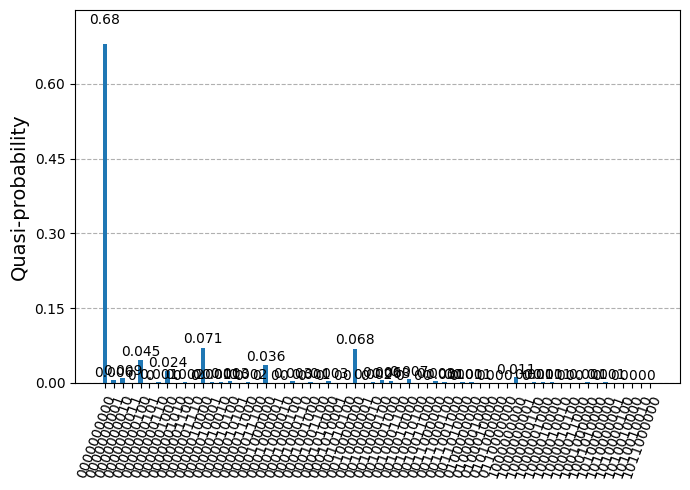

In [27]:
print("Contagem de bits:", counts_bit)
print("Contagem de inteiros:", counts)
print("Valor do produto interno:", counts.get(0, 0.0) / num_shots)

plot_distribution(counts_bit)

In [28]:
def visualize_counts(probs, num_qubits):
    zero_prob = probs.get(0, 0.0)
    top_10 = dict(sorted(probs.items(), key=lambda item: item[1], reverse=True) [:10])
    top_10. update({0: zero_prob})
    by_key = dict(sorted(top_10.items(), key=lambda item: item[0]))
    xvals, yvals = list(zip(*by_key.items()))
    xvals = [bin(xval)[2:].zfill(num_qubits) for xval in xvals]

    plt.bar(xvals, yvals)
    plt.xticks(rotation=75)
    plt.title("Resultados do produto interno")
    plt.xlabel("Bitstrings medidos")
    plt.ylabel("Contagens")
    plt.show()

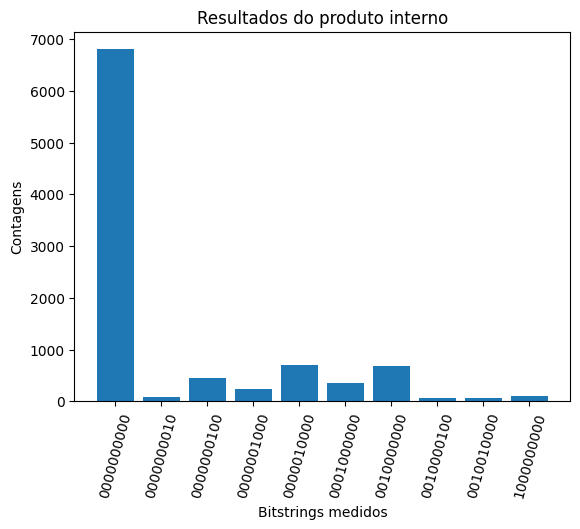

In [29]:
visualize_counts( counts, overlap_circ.num_qubits)

### FULL KERNEL MATRIX

In [30]:
!wget https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv

--2026-04-05 00:49:28--  https://raw.githubusercontent.com/qiskit-community/prototype-quantum-kernel-training/main/data/dataset_graph7.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49405 (48K) [text/plain]
Saving to: ‘dataset_graph7.csv.1’

dataset_graph7.csv. 100%[===================>]  48.25K  --.-KB/s    in 0.002s  

2026-04-05 00:49:28 (23.8 MB/s) - ‘dataset_graph7.csv.1’ saved [49405/49405]



In [31]:
df = pd.read_csv("dataset_graph7.csv", sep=",", header=None)


In [32]:
train_size = 90
X_train = df. values[0:train_size, :- 1]
train_labels = df. values[0:train_size, -1]

test_size = 30
X_test = df. values[train_size : train_size + test_size, :- 1]
test_labels = df.values[train_size : train_size + test_size, -1]

In [33]:
num_samples = np.shape(X_train)[0]
kernel_matrix = np.full((num_samples, num_samples), np.nan)
test_matrix = np.full((test_size, num_samples), np.nan)

In [34]:
num_features = np.shape(X_train)[1]
num_qubits = int(num_features / 2)
entangler_map = [[0,2], [3,4], [2,5], [1,4], [2,3], [4,6]]

In [35]:
fm = QuantumCircuit(num_qubits)
training_param = Parameter("0")
feature_params = ParameterVector("x", num_qubits * 2)
fm.ry(training_param, fm.qubits)

In [36]:
for cz in entangler_map:
    fm.cz(cz[0], cz[1])

for i in range(num_qubits):
    fm.rz(-2 * feature_params[2 * i+1], i)
    fm.rx(-2 * feature_params[2* i], i)

In [37]:
num_shots = 10000
sampler = StatevectorSampler()

In [38]:
for x1 in range(0, train_size):
    for x2 in range(x1 + 1, train_size):
        unitary1 = fm.assign_parameters(list(X_train[x1]) + [np.pi / 2])
        unitary2 = fm.assign_parameters(list(X_train[x2]) + [np.pi / 2])

        overlap_circ = unitary_overlap(unitary1, unitary2)
        overlap_circ.measure_all()

        counts = (
            sampler.run([overlap_circ], shots=num_shots)
            .result()[0]
            .data.meas.get_int_counts()
        )
        kernel_matrix[x1, x2] = counts.get(0, 0.0) / num_shots
        kernel_matrix[x2, x1] = counts.get(0, 0.0) / num_shots


    kernel_matrix[x1, x1] = 1

print("Treinamento concluído")

Treinamento concluído


In [39]:
for x1 in range(0, test_size):
    for x2 in range(0, train_size):
        unitary1 = fm.assign_parameters(list(X_test[x1]) + [np.pi / 2])
        unitary2 = fm.assign_parameters(list(X_train[x2]) + [np.pi / 2])

        overlap_circ = unitary_overlap(unitary1, unitary2)
        overlap_circ.measure_all()

        counts = (
            sampler.run([overlap_circ], shots=num_shots)
            .result()[0]
            .data.meas.get_int_counts()
        )
        test_matrix[x1, x2] = counts.get(0, 0.0) / num_shots

print("Matriz de teste concluída")


Matriz de teste concluída


In [40]:
qml_svc = SVC(kernel="precomputed")
qml_svc.fit(kernel_matrix, train_labels)
qml_score_precomputed_kernel = qml_svc.score(test_matrix, test_labels)

print("Score de teste em kernel classificado ML:", qml_score_precomputed_kernel)

Score de teste em kernel classificado ML: 0.4666666666666667


### FIM DA IMPLEMENTAÇÂO
---